# Ejemplo Práctico: Preprocesamiento con Adult Census Income Dataset

Este notebook demuestra técnicas avanzadas de preprocesamiento usando el **Adult Census Income Dataset** que presenta desafíos únicos como:
- Espacios en blanco en strings
- Datos faltantes representados como '?'
- Variables categóricas con many levels
- Inconsistencias en los datos

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer # para manejo de valores faltantes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Carga y Exploración Inicial

**Objetivo:** Cargar el dataset y entender su estructura básica

In [3]:
# Cargar datos desde URL de UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv(url, names=column_names, skipinitialspace=True)

print(f"Forma del dataset: {df.shape}")
print(f"\nPrimeras 5 filas:")
df.head()

Forma del dataset: (32561, 15)

Primeras 5 filas:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# Información básica del dataset
print("INFORMACIÓN DEL DATASET:")
print("="*50)
df.info()

print("\nESTADÍSTICAS DESCRIPTIVAS:")
print("="*50)
df.describe()

INFORMACIÓN DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

ESTADÍSTICAS DESCRIPTIVAS:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
# Identificar valores faltantes (representados como '?')
print("ANÁLISIS DE VALORES FALTANTES:")
print("="*50)

# Verificar qué columnas contienen '?'
missing_patterns = {}
for col in df.columns:
    missing_count = (df[col] == '?').sum()
    if missing_count > 0:
        missing_patterns[col] = missing_count

print(f"Columnas con valores '?': {missing_patterns}")
print(f"\nPorcentajes de valores faltantes:")
for col, count in missing_patterns.items():
    percentage = (count / len(df)) * 100
    print(f"{col}: {count} ({percentage:.2f}%)")

ANÁLISIS DE VALORES FALTANTES:
Columnas con valores '?': {'workclass': np.int64(1836), 'occupation': np.int64(1843), 'native-country': np.int64(583)}

Porcentajes de valores faltantes:
workclass: 1836 (5.64%)
occupation: 1843 (5.66%)
native-country: 583 (1.79%)


## 2. Limpieza Inicial de Datos

**Objetivo:** Limpiar inconsistencias básicas como espacios y caracteres especiales

In [7]:
# Función para limpiar strings
def clean_string_columns(df):
    """Limpia espacios en blanco y normaliza strings"""
    df_clean = df.copy()
    
    # Identificar columnas de tipo object (strings)
    string_columns = df_clean.select_dtypes(include=['object']).columns
    
    print("Limpiando columnas de texto:")
    for col in string_columns:
        # Mostrar valores únicos antes de la limpieza
        unique_values = df_clean[col].unique()
        print(f"\n{col} - Valores únicos: {len(unique_values)}")
        
        # Limpiar espacios al inicio y final
        df_clean[col] = df_clean[col].str.strip()
        
        # Convertir a lowercase para consistencia
        df_clean[col] = df_clean[col].str.lower()
        
        # Mostrar valores únicos después de la limpieza
        unique_after = df_clean[col].unique() # Obtener valores únicos después de limpieza
        if len(unique_after) != len(unique_values): # Si hubo cambio en la cantidad de valores únicos
            print(f"  → Reducido de {len(unique_values)} a {len(unique_after)} valores únicos")
    
    return df_clean

# Aplicar limpieza
df_clean = clean_string_columns(df)
print(f"\nForma después de limpieza: {df_clean.shape}")
print(df_clean.head())

Limpiando columnas de texto:

workclass - Valores únicos: 9

education - Valores únicos: 16

marital-status - Valores únicos: 7

occupation - Valores únicos: 15

relationship - Valores únicos: 6

race - Valores únicos: 5

sex - Valores únicos: 2

native-country - Valores únicos: 42

income - Valores únicos: 2

Forma después de limpieza: (32561, 15)
   age         workclass  fnlwgt  education  education-num  \
0   39         state-gov   77516  bachelors             13   
1   50  self-emp-not-inc   83311  bachelors             13   
2   38           private  215646    hs-grad              9   
3   53           private  234721       11th              7   
4   28           private  338409  bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       never-married       adm-clerical  not-in-family  white    male   
1  married-civ-spouse    exec-managerial        husband  white    male   
2            divorced  handlers-cleaners  not-in-famil

ANÁLISIS DE VALORES FALTANTES (POST-LIMPIEZA):
Columnas con valores '?': {'workclass': np.int64(1836), 'occupation': np.int64(1843), 'native-country': np.int64(583)}


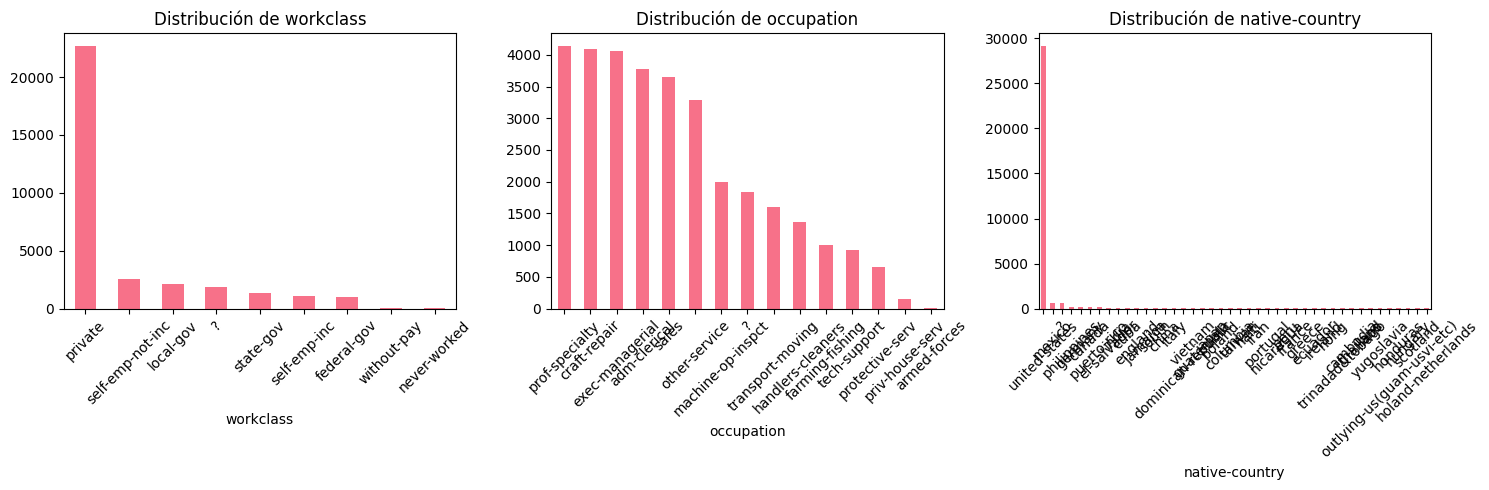

In [8]:
# Re-analizar valores faltantes después de limpieza
print("ANÁLISIS DE VALORES FALTANTES (POST-LIMPIEZA):")
print("="*60)

missing_patterns_clean = {}
for col in df_clean.columns:
    missing_count = (df_clean[col] == '?').sum()
    if missing_count > 0:
        missing_patterns_clean[col] = missing_count

print(f"Columnas con valores '?': {missing_patterns_clean}")

# Visualizar distribución de variables categóricas con valores faltantes
if missing_patterns_clean:
    fig, axes = plt.subplots(1, len(missing_patterns_clean), figsize=(15, 5))
    if len(missing_patterns_clean) == 1:
        axes = [axes]
    
    for idx, col in enumerate(missing_patterns_clean.keys()):
        value_counts = df_clean[col].value_counts()
        value_counts.plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(f'Distribución de {col}')
        axes[idx].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## 3. Análisis Exploratorio de Datos

**Objetivo:** Entender las distribuciones y relaciones entre variables

Variables categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


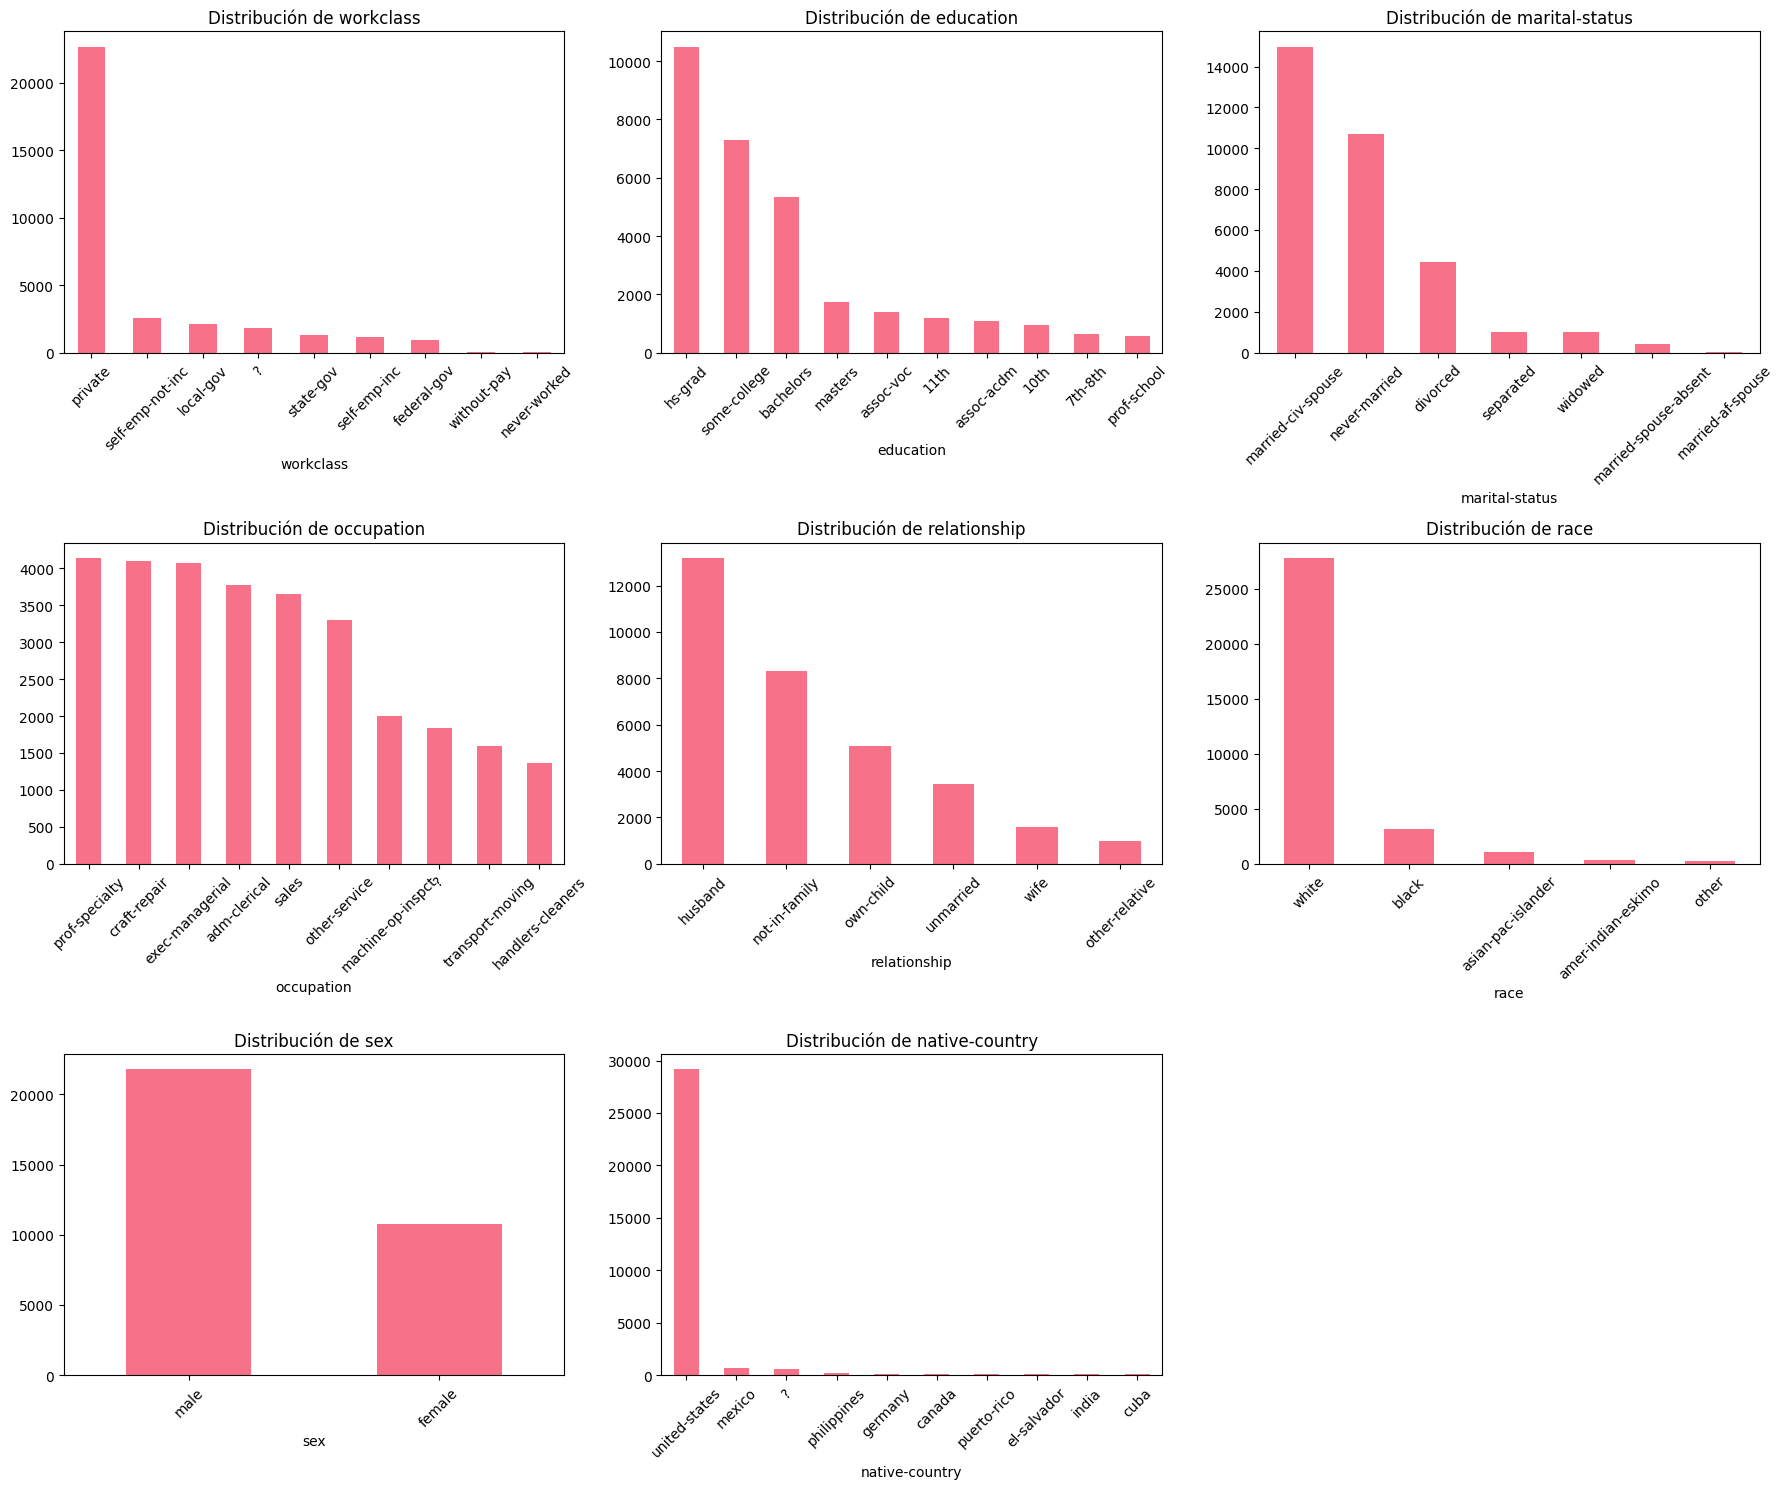

In [9]:
# Análisis de variables categóricas
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('income')  # Remover target variable

print(f"Variables categóricas: {categorical_cols}")

# Crear subplots para visualizar distribuciones
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols[:9]):
    if idx < len(axes):
        value_counts = df_clean[col].value_counts().head(10)  # Top 10 categorías
        value_counts.plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(f'Distribución de {col}')
        axes[idx].tick_params(axis='x', rotation=45)

# Ocultar subplots vacíos
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

Variables numéricas: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


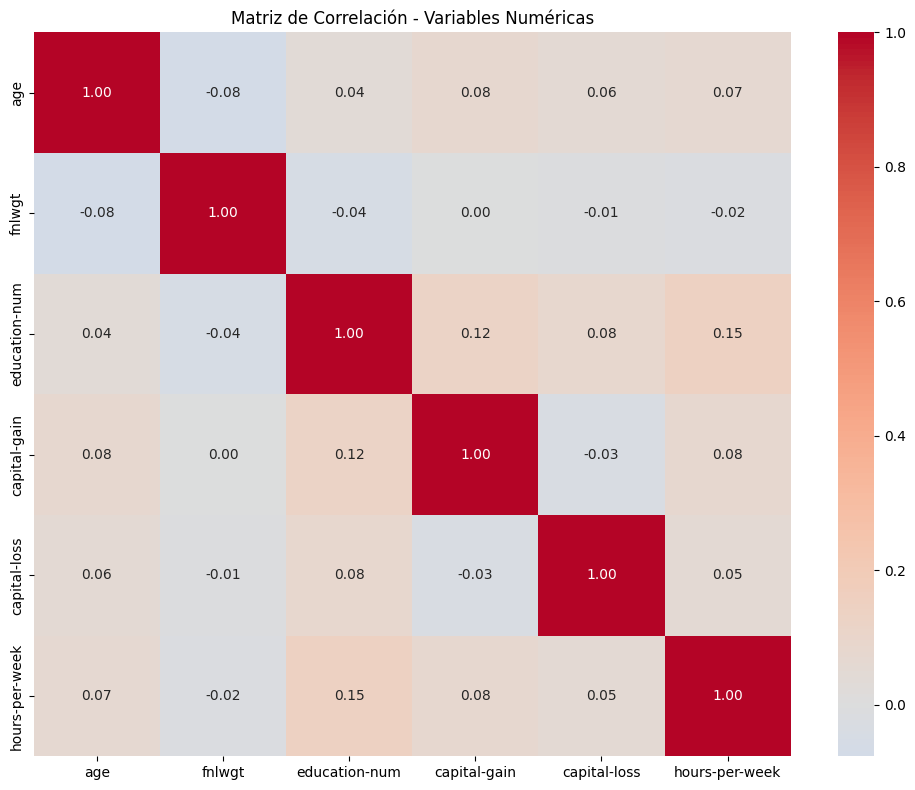

In [10]:
# Análisis de correlaciones para variables numéricas
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variables numéricas: {numerical_cols}")

# Calcular matriz de correlación
correlation_matrix = df_clean[numerical_cols].corr()

# Visualizar matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

## 4. Estrategias para Manejo de Valores Faltantes

**Objetivo:** Aplicar diferentes técnicas de imputación según el tipo de variable

In [11]:
# Función para analizar patrones de valores faltantes
def analyze_missing_patterns(df, missing_cols):
    """Analiza patrones de valores faltantes"""
    print("ANÁLISIS DE PATRONES DE VALORES FALTANTES:")
    print("="*60)
    
    for col in missing_cols:
        print(f"\n{col.upper()}:") # Analizar cada columna con valores faltantes
        
        # Valores más frecuentes cuando no es missing
        non_missing = df[df[col] != '?'][col] # Filtrar no missing
        print(f"  Valores más frecuentes: {non_missing.value_counts().head(3).to_dict()}")
        
        # Relación con variable target
        missing_mask = df[col] == '?'
        target_distribution = df[missing_mask]['income'].value_counts()
        print(f"  Distribución target cuando missing: {target_distribution.to_dict()}")

# Analizar patrones
analyze_missing_patterns(df_clean, missing_patterns_clean.keys())

ANÁLISIS DE PATRONES DE VALORES FALTANTES:

WORKCLASS:
  Valores más frecuentes: {'private': 22696, 'self-emp-not-inc': 2541, 'local-gov': 2093}
  Distribución target cuando missing: {'<=50k': 1645, '>50k': 191}

OCCUPATION:
  Valores más frecuentes: {'prof-specialty': 4140, 'craft-repair': 4099, 'exec-managerial': 4066}
  Distribución target cuando missing: {'<=50k': 1652, '>50k': 191}

NATIVE-COUNTRY:
  Valores más frecuentes: {'united-states': 29170, 'mexico': 643, 'philippines': 198}
  Distribución target cuando missing: {'<=50k': 437, '>50k': 146}


In [12]:
# Estrategia 1: Imputación por moda (más frecuente)
def impute_by_mode(df, column):
    """Imputa valores faltantes con la moda"""
    df_imputed = df.copy()
    
    # Calcular moda (excluyendo '?')
    mode_value = df[df[column] != '?'][column].mode()[0]
    
    print(f"Imputando {column} con modo: '{mode_value}'")
    
    # Reemplazar '?' con la moda
    missing_count = (df[column] == '?').sum()
    df_imputed[column] = df_imputed[column].replace('?', mode_value)
    
    print(f"  → {missing_count} valores faltantes reemplazados")
    
    return df_imputed

# Aplicar imputación por modo a todas las columnas con missing
df_imputed_mode = df_clean.copy()
for col in missing_patterns_clean.keys():
    df_imputed_mode = impute_by_mode(df_imputed_mode, col)

print(f"\nVerificación: ¿Quedan valores '?'?")
remaining_missing = (df_imputed_mode == '?').sum().sum()
print(f"Total de valores '?' restantes: {remaining_missing}")

Imputando workclass con modo: 'private'
  → 1836 valores faltantes reemplazados
Imputando occupation con modo: 'prof-specialty'
  → 1843 valores faltantes reemplazados
Imputando native-country con modo: 'united-states'
  → 583 valores faltantes reemplazados

Verificación: ¿Quedan valores '?'?
Total de valores '?' restantes: 0


In [13]:
# Estrategia 2: Imputación basada en variables similares
# Para workclass y occupation, usamos education como guía
def conditional_imputation(df):
    """Imputa valores faltantes basándose en otras variables"""
    df_cond = df.copy()
    
    # Analizar patrones de trabajo según educación
    print("ANÁLISIS DE PATRONES PARA IMPUTACIÓN CONDICIONAL:")
    print("="*60)
    
    # Workclass por educación
    education_workclass = df[df['workclass'] != '?'].groupby('education')['workclass'].apply(
        lambda x: x.mode()[0] if len(x.mode()) > 0 else 'private' # Valor por defecto
    )
    print("Workclass más común por educación:")
    for edu, workclass in education_workclass.head().items():
        print(f"  {edu}: {workclass}")
    
    return df_cond

# Aplicar análisis
df_cond_analysis = conditional_imputation(df_clean)

# Mostrar recomendaciones de imputación
print("\nRECOMENDACIONES DE IMPUTACIÓN:")
print("="*40)
print("1. workclass: Imputar con 'private' (mayoría de casos)")
print("2. occupation: Crear categoría 'unknown' o imputar por educación")
print("3. native-country: Imputar con 'united-states' (mayoría)")

ANÁLISIS DE PATRONES PARA IMPUTACIÓN CONDICIONAL:
Workclass más común por educación:
  10th: private
  11th: private
  12th: private
  1st-4th: private
  5th-6th: private

RECOMENDACIONES DE IMPUTACIÓN:
1. workclass: Imputar con 'private' (mayoría de casos)
2. occupation: Crear categoría 'unknown' o imputar por educación
3. native-country: Imputar con 'united-states' (mayoría)


## 5. Ingeniería de Características

**Objetivo:** Crear nuevas características útiles para el modelo

In [14]:
# Crear nuevas características
def create_new_features(df):
    """Crea nuevas características basadas en las existentes"""
    df_featured = df.copy()
    
    # 1. Age groups
    df_featured['age_group'] = pd.cut(df_featured['age'], 
                                    bins=[0, 25, 35, 50, 65, 100], 
                                    labels=['young', 'adult', 'middle', 'senior', 'elderly'])
    
    # 2. Capital features
    df_featured['has_capital_gain'] = (df_featured['capital-gain'] > 0).astype(int) # Indicador binario
    df_featured['has_capital_loss'] = (df_featured['capital-loss'] > 0).astype(int) # Indicador binario
    df_featured['net_capital'] = df_featured['capital-gain'] - df_featured['capital-loss'] # Ganancia neta de capital
    
    # 3. Work intensity
    df_featured['work_intensity'] = pd.cut(df_featured['hours-per-week'], 
                                          bins=[0, 20, 40, 60, 100], 
                                          labels=['part_time', 'full_time', 'overtime', 'workaholic'])
    
    # 4. Education level groups
    education_mapping = {
        'preschool': 'basic', '1st-4th': 'basic', '5th-6th': 'basic', '7th-8th': 'basic',
        '9th': 'basic', '10th': 'basic', '11th': 'basic', '12th': 'basic',
        'hs-grad': 'high_school', 'some-college': 'some_college', 'assoc-voc': 'some_college',
        'assoc-acdm': 'some_college', 'bachelors': 'bachelors', 'masters': 'advanced',
        'prof-school': 'advanced', 'doctorate': 'advanced'
    }
    df_featured['education_level'] = df_featured['education'].map(education_mapping) # Nivel educativo agrupado
    
    # 5. Marital status groups
    df_featured['is_married'] = df_featured['marital-status'].str.contains('married', case=False).astype(int)
    
    print(f"Nuevas características creadas:")
    print(f"- age_group: grupos etarios")
    print(f"- has_capital_gain/loss: indicadores binarios")
    print(f"- net_capital: ganancia neta de capital")
    print(f"- work_intensity: intensidad laboral")
    print(f"- education_level: nivel educativo agrupado")
    print(f"- is_married: estado civil simplificado")
    
    return df_featured

# Aplicar ingeniería de características
df_featured = create_new_features(df_imputed_mode)
print(f"\nForma del dataset con nuevas características: {df_featured.shape}")

Nuevas características creadas:
- age_group: grupos etarios
- has_capital_gain/loss: indicadores binarios
- net_capital: ganancia neta de capital
- work_intensity: intensidad laboral
- education_level: nivel educativo agrupado
- is_married: estado civil simplificado

Forma del dataset con nuevas características: (32561, 22)


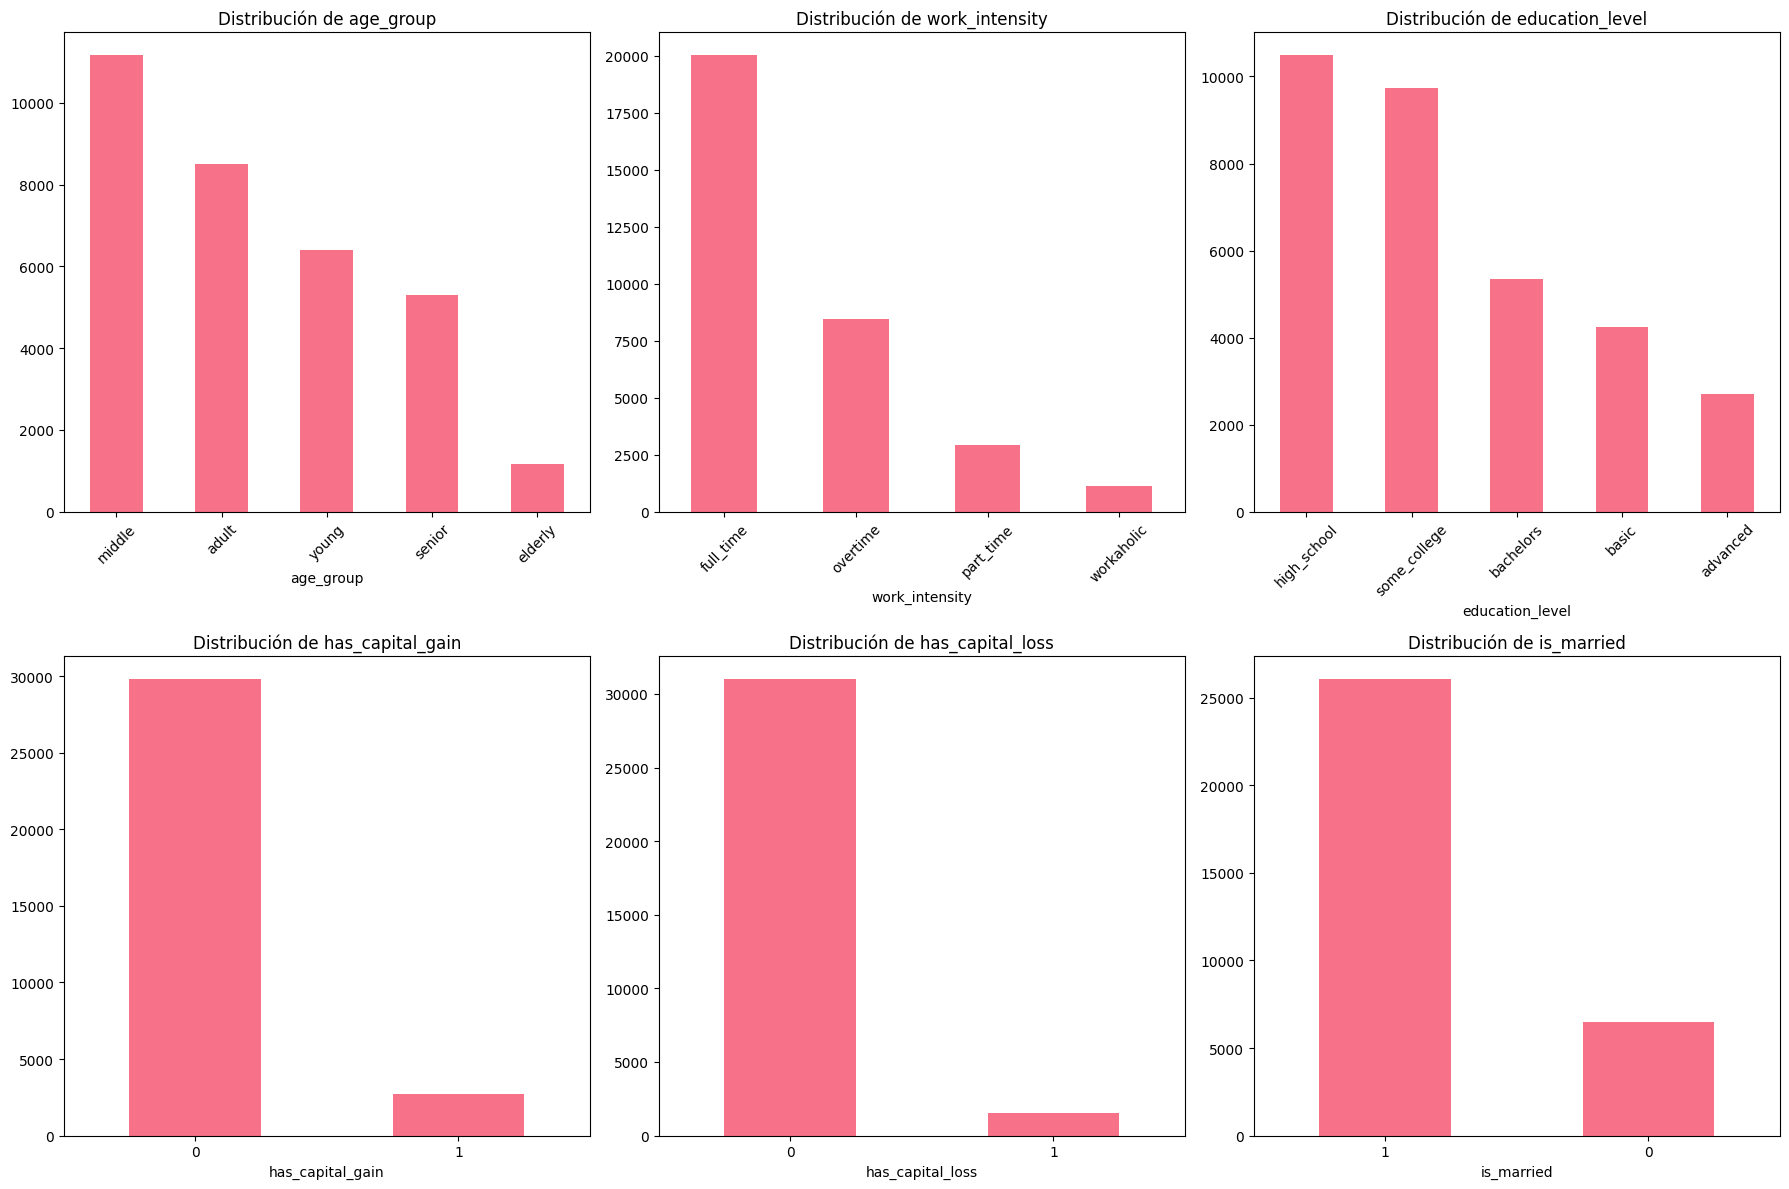

In [15]:
# Visualizar las nuevas características
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Nuevas características categóricas
new_cat_features = ['age_group', 'work_intensity', 'education_level']
for idx, feature in enumerate(new_cat_features[:3]):
    df_featured[feature].value_counts().plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'Distribución de {feature}')
    axes[idx].tick_params(axis='x', rotation=45)

# Nuevas características binarias
new_bin_features = ['has_capital_gain', 'has_capital_loss', 'is_married']
for idx, feature in enumerate(new_bin_features):
    feature_idx = idx + 3
    df_featured[feature].value_counts().plot(kind='bar', ax=axes[feature_idx])
    axes[feature_idx].set_title(f'Distribución de {feature}')
    axes[feature_idx].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. Encoding de Variables Categóricas

**Objetivo:** Convertir variables categóricas a formato numérico

In [16]:
# Análisis de cardinalidad de variables categóricas
def analyze_cardinality(df):
    """Analiza la cardinalidad de variables categóricas"""
    print("ANÁLISIS DE CARDINALIDAD:")
    print("="*50)
    
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if 'income' in categorical_cols:
        categorical_cols.remove('income')
    
    cardinality_info = {}
    for col in categorical_cols:
        unique_count = df[col].nunique()
        cardinality_info[col] = unique_count
        print(f"{col}: {unique_count} valores únicos")
    
    # Clasificar por cardinalidad
    low_card = [k for k, v in cardinality_info.items() if v <= 10]
    medium_card = [k for k, v in cardinality_info.items() if 10 < v <= 50]
    high_card = [k for k, v in cardinality_info.items() if v > 50]
    
    print(f"\nCLASIFICACIÓN POR CARDINALIDAD:")
    print(f"Baja (≤10): {low_card}")
    print(f"Media (11-50): {medium_card}")
    print(f"Alta (>50): {high_card}")
    
    return cardinality_info, low_card, medium_card, high_card

cardinality, low_card, medium_card, high_card = analyze_cardinality(df_featured)

ANÁLISIS DE CARDINALIDAD:
workclass: 8 valores únicos
education: 16 valores únicos
marital-status: 7 valores únicos
occupation: 14 valores únicos
relationship: 6 valores únicos
race: 5 valores únicos
sex: 2 valores únicos
native-country: 41 valores únicos
age_group: 5 valores únicos
work_intensity: 4 valores únicos
education_level: 5 valores únicos

CLASIFICACIÓN POR CARDINALIDAD:
Baja (≤10): ['workclass', 'marital-status', 'relationship', 'race', 'sex', 'age_group', 'work_intensity', 'education_level']
Media (11-50): ['education', 'occupation', 'native-country']
Alta (>50): []


In [17]:
# Función para aplicar diferentes estrategias de encoding
def apply_encoding_strategies(df, low_card, medium_card, high_card):
    """Aplica diferentes estrategias de encoding según cardinalidad"""
    df_encoded = df.copy()
    
    print("APLICANDO ESTRATEGIAS DE ENCODING:")
    print("="*50)
    
    # 1. One-Hot Encoding para baja cardinalidad
    print("\n1. One-Hot Encoding (baja cardinalidad):")
    for col in low_card:
        unique_values = df_encoded[col].unique()
        print(f"   {col}: {len(unique_values)} categorías")
        
        # Crear dummies
        dummies = pd.get_dummies(df_encoded[col], prefix=col, drop_first=True)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        
        # Remover columna original
        df_encoded = df_encoded.drop(col, axis=1)
    
    # 2. Label Encoding para media cardinalidad (con grouping de rare categories)
    print("\n2. Label Encoding (media cardinalidad):")
    for col in medium_card:
        print(f"   {col}: {df_encoded[col].nunique()} categorías")
        
        # Agrupar categorías raras (menos del 5% de los datos)
        value_counts = df_encoded[col].value_counts()
        rare_categories = value_counts[value_counts < len(df_encoded) * 0.05].index.tolist()
        
        if rare_categories:
            print(f"     → Agrupando {len(rare_categories)} categorías raras")
            df_encoded[col] = df_encoded[col].replace(rare_categories, 'other')
        
        # Label encoding es una función que me permite convertir etiquetas en números
        le = LabelEncoder() # Inicializar codificador
        df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col]) # Nueva columna codificada
        df_encoded = df_encoded.drop(col, axis=1) # Remover columna original
    
    # 3. Frequency/Target encoding para alta cardinalidad
    print("\n3. Frequency Encoding (alta cardinalidad):")
    for col in high_card:
        print(f"   {col}: {df_encoded[col].nunique()} categorías")
        
        # Frequency encoding
        freq_map = df_encoded[col].value_counts().to_dict() # Mapa de frecuencias, esto nos permite tener una representación numérica de las categorías
        df_encoded[col + '_freq'] = df_encoded[col].map(freq_map) # Nueva columna de frecuencias
        df_encoded = df_encoded.drop(col, axis=1) # Remover columna original
    
    return df_encoded

# Aplicar encoding
df_encoded = apply_encoding_strategies(df_featured, low_card, medium_card, high_card)
print(f"\nForma del dataset después del encoding: {df_encoded.shape}")
print(df_encoded.head())

APLICANDO ESTRATEGIAS DE ENCODING:

1. One-Hot Encoding (baja cardinalidad):
   workclass: 8 categorías
   marital-status: 7 categorías
   relationship: 6 categorías
   race: 5 categorías
   sex: 2 categorías
   age_group: 5 categorías
   work_intensity: 4 categorías
   education_level: 5 categorías

2. Label Encoding (media cardinalidad):
   education: 16 categorías
     → Agrupando 12 categorías raras
   occupation: 14 categorías
     → Agrupando 7 categorías raras
   native-country: 41 categorías
     → Agrupando 40 categorías raras

3. Frequency Encoding (alta cardinalidad):

Forma del dataset después del encoding: (32561, 48)
   age  fnlwgt  education-num  capital-gain  capital-loss  hours-per-week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0          

## 7. Escalado de Variables

**Objetivo:** Normalizar las variables para algoritmos sensibles a escala

Variables numéricas a escalar: 13
Variables: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'has_capital_gain', 'has_capital_loss', 'net_capital', 'is_married']...


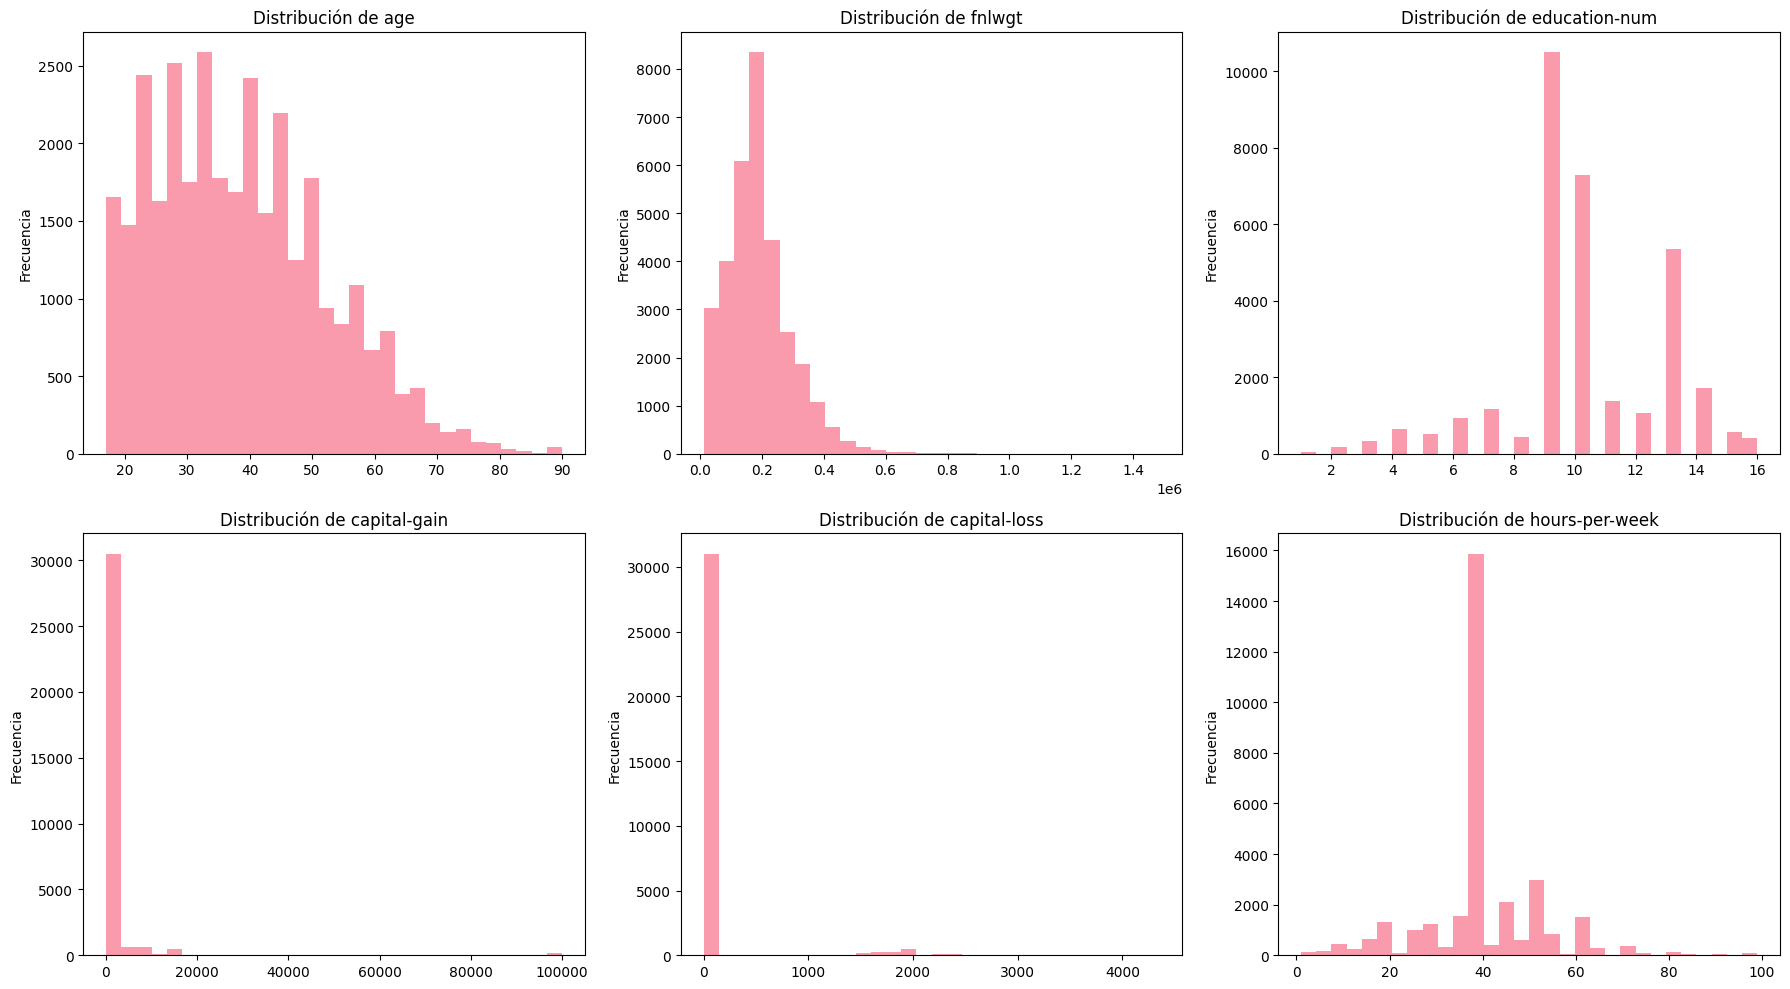


ESTADÍSTICAS ANTES DEL ESCALADO:
                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  has_capital_gain  has_capital_loss   net_capital  \
count    32561.000000      32561.000000      32561.000000  32561.000000   
mean        40.437456          0.083290          0.046651    990.345014   
std         12.34742

In [18]:
# Análisis de distribuciones antes del escalado
numerical_features = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [col for col in numerical_features if col != 'income_encoded']

print(f"Variables numéricas a escalar: {len(numerical_features)}")
print(f"Variables: {numerical_features[:10]}...")  # Mostrar primeras 10

# Visualizar distribuciones antes del escalado
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features[:6]):
    axes[idx].hist(df_encoded[col], bins=30, alpha=0.7)
    axes[idx].set_title(f'Distribución de {col}')
    axes[idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas antes del escalado
print("\nESTADÍSTICAS ANTES DEL ESCALADO:")
print("="*40)
print(df_encoded[numerical_features].describe())

In [19]:
# Aplicar diferentes métodos de escalado
def apply_scaling_methods(df, numerical_features):
    """Aplica diferentes métodos de escalado"""
    
    # 1. StandardScaler
    scaler_standard = StandardScaler()
    df_standard = df.copy()
    df_standard[numerical_features] = scaler_standard.fit_transform(df[numerical_features])
    
    # 2. RobustScaler (menos sensible a outliers)
    from sklearn.preprocessing import RobustScaler
    scaler_robust = RobustScaler()
    df_robust = df.copy()
    df_robust[numerical_features] = scaler_robust.fit_transform(df[numerical_features])
    
    print("MÉTODOS DE ESCALADO APLICADOS:")
    print("="*40)
    print("1. StandardScaler: Media=0, Std=1")
    print("2. RobustScaler: Mediana=0, IQR scaling")
    
    # Comparar estadísticas
    print("\nCOMPARACIÓN DE ESTADÍSTICAS:")
    print("Standard Scaler:")
    print(df_standard[numerical_features].describe().iloc[[1,2,7],:3])  # mean, std, max
    
    print("\nRobust Scaler:")
    print(df_robust[numerical_features].describe().iloc[[1,2,7],:3])
    
    return df_standard, df_robust, scaler_standard, scaler_robust

df_scaled, df_robust, scaler_std, scaler_rob = apply_scaling_methods(df_encoded, numerical_features)

MÉTODOS DE ESCALADO APLICADOS:
1. StandardScaler: Media=0, Std=1
2. RobustScaler: Mediana=0, IQR scaling

COMPARACIÓN DE ESTADÍSTICAS:
Standard Scaler:
               age        fnlwgt  education-num
mean -2.662271e-17 -9.732565e-17   1.479525e-16
std   1.000015e+00  1.000015e+00   1.000015e+00
max   3.769612e+00  1.226856e+01   2.300838e+00

Robust Scaler:
           age     fnlwgt  education-num
mean  0.079082   0.095806       0.026893
std   0.682022   0.885308       0.857573
max   2.650000  10.957098       2.000000


## 8. Preparación Final del Dataset

**Objetivo:** Finalizar la preparación y preparar datos para modelado

In [20]:
# Función final de preprocesamiento
def final_preprocessing_pipeline(df_raw):
    """Pipeline completo de preprocesamiento"""
    
    print("EJECUTANDO PIPELINE COMPLETO DE PREPROCESAMIENTO:")
    print("="*60)
    
    # Paso 1: Limpieza básica
    df = df_raw.copy()
    df = clean_string_columns(df)
    
    # Paso 2: Manejo de valores faltantes
    for col in ['workclass', 'occupation', 'native-country']:
        if col in df.columns:
            df[col] = df[col].replace('?', df[df[col] != '?'][col].mode()[0])
    
    # Paso 3: Ingeniería de características
    df = create_new_features(df)
    
    # Paso 4: Encoding
    cardinality, low_card, med_card, high_card = analyze_cardinality(df)
    df = apply_encoding_strategies(df, low_card, med_card, high_card)
    
    # Paso 5: Escalado
    df[numerical_features] = scaler_std.fit_transform(df[numerical_features])
    
    # Paso 6: Preparar target variable
    le_target = LabelEncoder()
    df['target'] = le_target.fit_transform(df['income'])
    
    # Remover columnas innecesarias
    columns_to_remove = ['income', 'age_group', 'work_intensity', 'education_level']
    for col in columns_to_remove:
        if col in df.columns:
            df = df.drop(col, axis=1)
    
    print(f"\nDataset final shape: {df.shape}")
    print(f"Características finales: {list(df.columns)}")
    
    return df, le_target

# Ejecutar pipeline completo
df_final, label_encoder_target = final_preprocessing_pipeline(df)

# Verificar resultado final
print(f"\nVERIFICACIÓN FINAL:")
print("="*30)
print(f"Forma final: {df_final.shape}")
print(f"Valores faltantes: {df_final.isnull().sum().sum()}")
print(f"Tipo de datos:")
print(df_final.dtypes.value_counts())

EJECUTANDO PIPELINE COMPLETO DE PREPROCESAMIENTO:
Limpiando columnas de texto:

workclass - Valores únicos: 9

education - Valores únicos: 16

marital-status - Valores únicos: 7

occupation - Valores únicos: 15

relationship - Valores únicos: 6

race - Valores únicos: 5

sex - Valores únicos: 2

native-country - Valores únicos: 42

income - Valores únicos: 2
Nuevas características creadas:
- age_group: grupos etarios
- has_capital_gain/loss: indicadores binarios
- net_capital: ganancia neta de capital
- work_intensity: intensidad laboral
- education_level: nivel educativo agrupado
- is_married: estado civil simplificado
ANÁLISIS DE CARDINALIDAD:
workclass: 8 valores únicos
education: 16 valores únicos
marital-status: 7 valores únicos
occupation: 14 valores únicos
relationship: 6 valores únicos
race: 5 valores únicos
sex: 2 valores únicos
native-country: 41 valores únicos
age_group: 5 valores únicos
work_intensity: 4 valores únicos
education_level: 5 valores únicos

CLASIFICACIÓN POR CA

## 9. Validación del Preprocesamiento

**Objetivo:** Validar que el preprocesamiento mejora el rendimiento del modelo

In [21]:
# Dividir en entrenamiento y prueba
X = df_final.drop('target', axis=1)
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"CONJUNTOS DE ENTRENAMIENTO Y PRUEBA:")
print("="*45)
print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")
print(f"Distribución target en entrenamiento: {np.bincount(y_train)}")
print(f"Distribución target en prueba: {np.bincount(y_test)}")

# Entrenar modelo con datos preprocesados
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluar modelo
y_pred = rf_model.predict(X_test)

print("\nRESULTADOS DEL MODELO:")
print("="*30)
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

# Mostrar importancia de características
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:")
print("="*50)
for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

CONJUNTOS DE ENTRENAMIENTO Y PRUEBA:
Entrenamiento: (26048, 47)
Prueba: (6513, 47)
Distribución target en entrenamiento: [19775  6273]
Distribución target en prueba: [4945 1568]

RESULTADOS DEL MODELO:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      4945
        >50K       0.73      0.62      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513


TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES:
fnlwgt: 0.1625
age: 0.1241
marital-status_married-civ-spouse: 0.0929
education-num: 0.0728
net_capital: 0.0720
occupation_encoded: 0.0623
hours-per-week: 0.0614
capital-gain: 0.0526
marital-status_never-married: 0.0234
capital-loss: 0.0201


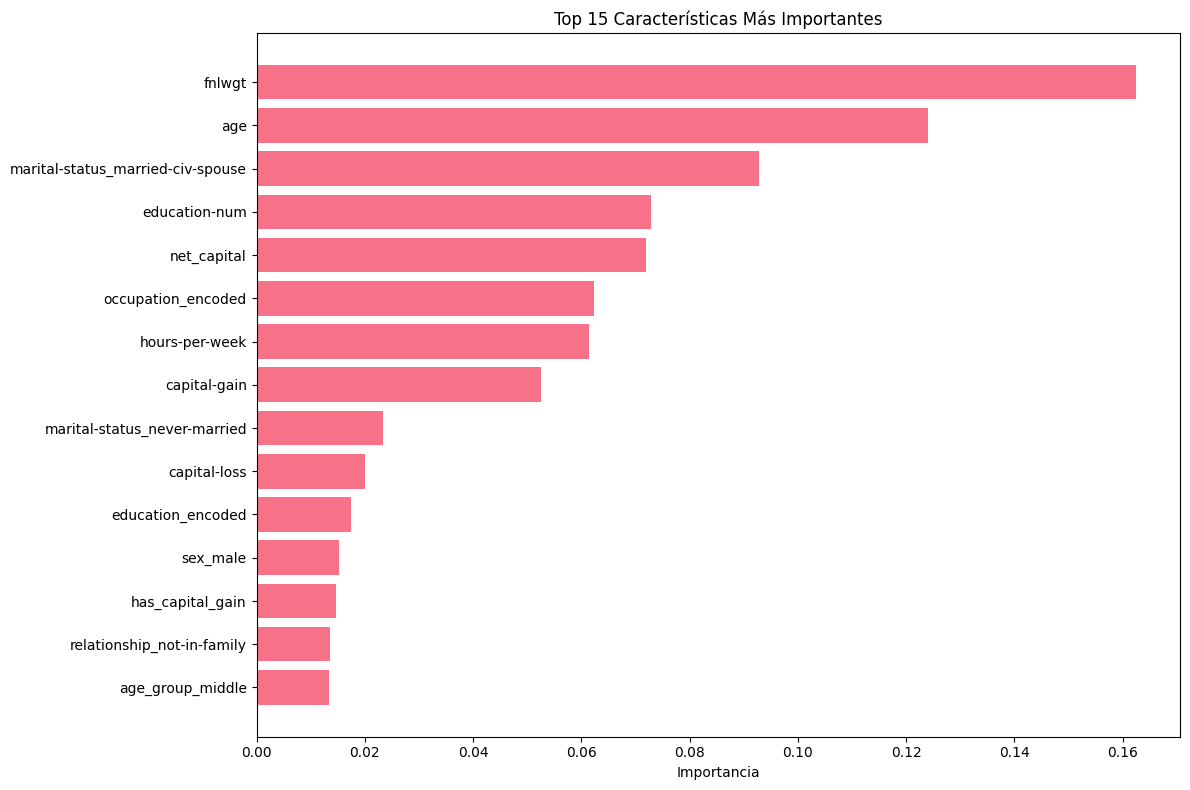

In [22]:
# Visualizar importancia de características
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importancia')
plt.title('Top 15 Características Más Importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Resumen y Mejores Prácticas

**Objetivo:** Consolidar aprendizajes y mejores prácticas

In [23]:
print("RESUMEN DEL PREPROCESAMIENTO APLICADO:")
print("="*60)

print("\n1. LIMPIEZA INICIAL:")
print("   ✓ Eliminación de espacios en blanco")
print("   ✓ Normalización de strings (lowercase)")
print("   ✓ Identificación de patrones de datos faltantes")

print("\n2. MANEJO DE VALORES FALTANTES:")
print("   ✓ Análisis de patrones MCAR/MAR")
print("   ✓ Imputación por moda para variables categóricas")
print("   ✓ Estrategias específicas según el contexto")

print("\n3. INGENIERÍA DE CARACTERÍSTICAS:")
print("   ✓ Creación de grupos etarios")
print("   ✓ Indicadores binarios (capital gain/loss)")
print("   ✓ Agrupación de niveles educativos")
print("   ✓ Simplificación de estados civiles")

print("\n4. ENCODING DE VARIABLES:")
print("   ✓ One-hot encoding para baja cardinalidad")
print("   ✓ Label encoding para media cardinalidad")
print("   ✓ Frequency encoding para alta cardinalidad")
print("   ✓ Agrupación de categorías raras")

print("\n5. ESCALADO:")
print("   ✓ StandardScaler para normalizar distribuciones")
print("   ✓ Aplicación consistente en train/test")

print("\n6. VALIDACIÓN:")
print("   ✓ División estratificada train/test")
print("   ✓ Evaluación con Random Forest")
print("   ✓ Análisis de importancia de características")

print(f"\nRESULTADO FINAL:")
print("="*30)
print(f"• Características originales: 14")
print(f"• Características finales: {df_final.shape[1]}")
print(f"• Mejora en dimensionalidad: +{df_final.shape[1] - 14} características")
print(f"• Sin valores faltantes: ✓")
print(f"• Datos escalados: ✓")
print(f"• Listos para modelado: ✓")

RESUMEN DEL PREPROCESAMIENTO APLICADO:

1. LIMPIEZA INICIAL:
   ✓ Eliminación de espacios en blanco
   ✓ Normalización de strings (lowercase)
   ✓ Identificación de patrones de datos faltantes

2. MANEJO DE VALORES FALTANTES:
   ✓ Análisis de patrones MCAR/MAR
   ✓ Imputación por moda para variables categóricas
   ✓ Estrategias específicas según el contexto

3. INGENIERÍA DE CARACTERÍSTICAS:
   ✓ Creación de grupos etarios
   ✓ Indicadores binarios (capital gain/loss)
   ✓ Agrupación de niveles educativos
   ✓ Simplificación de estados civiles

4. ENCODING DE VARIABLES:
   ✓ One-hot encoding para baja cardinalidad
   ✓ Label encoding para media cardinalidad
   ✓ Frequency encoding para alta cardinalidad
   ✓ Agrupación de categorías raras

5. ESCALADO:
   ✓ StandardScaler para normalizar distribuciones
   ✓ Aplicación consistente en train/test

6. VALIDACIÓN:
   ✓ División estratificada train/test
   ✓ Evaluación con Random Forest
   ✓ Análisis de importancia de características

RESULT

## EJERCICIOS PARA PRACTICAR

**Intenta estos ejercicios para dominar las técnicas:**

### Ejercicio 1: Variaciones en Imputación
- Prueba diferentes estrategias para `workclass`:
  - Imputación por educación
  - Crear categoría 'unknown'
  - Análisis de correlación para imputación inteligente

### Ejercicio 2: Nuevas Características
- Crea características adicionales:
  - Ratio capital gain/loss
  - Indicador de trabajo en fin de semana
  - Combinaciones de educación y ocupación

### Ejercicio 3: Comparación de Modelos
- Aplica el preprocesamiento a:
  - Logistic Regression
  - Support Vector Machine
  - Gradient Boosting
- Compara performance entre algoritmos

### Ejercicio 4: Validación Cruzada
- Implementa k-fold cross validation
- Analiza estabilidad de métricas
- Identifica overfitting vs underfitting

### Ejercicio 5: Feature Selection
- Aplica técnicas de selección:
  - Remove constant features
  - Correlation-based selection
  - Recursive feature elimination
- Compara con todas las características